# Catboost Predict Event Age

In [1]:
#!uv pip install shap
#!uv pip install catboost

In [2]:
import os
import glob
import numpy as np
import altair as alt
import polars as pl
import pandas as pd
import shap
from catboost import CatBoostRegressor, Pool


from birds.source_data.nabbp import LookupTables, DataTables
from birds.source_data.iucn import IUCNDataTables
from birds.settings import load_settings, get_relative_path


from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Settings

In [3]:
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [5]:
settings = load_settings()
lookup = LookupTables()

In [6]:
modelpath = get_relative_path(settings.model_path)

## Load Data

In [7]:
def load_agg_data_files(nfiles):
    data_dir = get_relative_path(get_relative_path(settings.augmented_band_agg))
    print(data_dir)

    all_files = sorted(glob.glob(os.path.join(data_dir, "nabbp_band_agg_*.parquet")))

    if nfiles > 0:
        all_files = all_files[-nfiles:]
    
    print(f"Loading {len(all_files)} files from {data_dir}")
    df = pl.concat([pl.read_parquet(f) for f in all_files])
    return df


df = load_agg_data_files(99)

data/augmented_data/band_agg
Loading 57 files from data/augmented_data/band_agg


In [8]:
df.head()

banding_record_id,banding_band,banding_date,banding_day,banding_month,banding_year,banding_species_id,banding_iso_country,banding_iso_subdivision,banding_band_type_code,banding_bird_status,banding_age_code,banding_sex_code,banding_event_type,banding_band_status_code,banding_extra_info_code,banding_lat_dd,banding_lon_dd,banding_coordinates_precision_code,banding_permit,banding_record_source,num_events,last_event_date,last_how_obtained_code,last_who_obtained_code,last_reporting_method,last_present_condition,last_lat_dd,last_lon_dd,last_iso_country,last_iso_subdivision,event_days_span,first_to_last_km,num_event_days_span
i64,str,date,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,i64,date,i64,i64,i64,i64,f64,f64,str,str,i64,f64,i64
-42574156,"""B58235077397""",2005-07-29,29,7,2005,1691,"""CA""","""CA-ON""","""1""","""3""","""1""","""5""","""B""","""0""","""00""",55.5,-83.5,"""60.0""","""P8832232""","""B""",1,2005-10-13,1,21,6,3,52.41667,-109.25,"""CA""","""CA-SK""",76,1708.745971,76
-16205515,"""B17815174927""",2017-07-15,15,7,2017,1710,"""CA""","""CA-NU""","""41""","""3""","""1""","""5""","""B""","""0""","""00""",67.5,-101.5,"""60.0""","""P7837928""","""B""",1,2018-12-08,1,21,7,5,34.30495,-91.98342,"""US""","""US-AR""",511,3741.442839,511
19818780,"""B67765371626""",2023-07-19,19,7,2023,1690,"""CA""","""CA-NT""","""9999""","""3""","""5""","""5""","""B""","""0""","""00""",72.5,-124.5,"""60.0""","""P8830613""","""B""",1,2025-04-09,1,21,7,5,50.57183,-112.95173,"""CA""","""CA-AB""",630,2503.432432,630
-42853666,"""B88845010098""",1976-10-29,29,10,1976,1690,"""US""","""US-NE""","""11""","""3""","""1""","""5""","""B""","""0""","""19""",41.5,-96.5,"""60.0""","""P9953434""","""B""",1,1981-12-06,1,20,1,5,40.75,-95.58333,"""US""","""US-IA""",1864,113.357308,1864
-42949648,"""B48495419884""",2003-08-02,2,8,2003,1690,"""US""","""US-AK""","""1""","""3""","""4""","""4""","""B""","""0""","""00""",70.5,-154.5,"""60.0""","""P4741797""","""B""",1,2009-05-22,1,21,61,5,69.41667,-130.25,"""CA""","""CA-NT""",2120,925.553743,2120


## Prepare Data

In [9]:
cat_cols = [ 'banding_species_id','banding_iso_country', 'banding_iso_subdivision','banding_band_type_code','banding_bird_status',
               'banding_age_code', 'banding_sex_code', 'banding_event_type', 'banding_band_status_code', 'banding_extra_info_code',
               'banding_coordinates_precision_code', 'banding_permit', 'banding_day', 'banding_month', 'banding_year', 'banding_record_source',            
]

banding_columns = [
 'banding_day',
 'banding_month',
 'banding_year',
 'banding_species_id',
 'banding_iso_country',
 'banding_iso_subdivision',
 'banding_band_type_code',
 'banding_bird_status',
 'banding_age_code',
 'banding_sex_code',
 'banding_event_type',
 'banding_band_status_code',
 'banding_extra_info_code',
 'banding_lat_dd',
 'banding_lon_dd',
 'banding_coordinates_precision_code',
 'banding_permit',
 'banding_record_source',
 'event_days_span'
]

#filter df to only banding columns
df_banding = df.select(banding_columns)

In [10]:
df_banding_pd = df_banding.to_pandas()

In [11]:
# remove species ids with less than 10 records.   Needed for reasonable train/test split
species_counts = df_banding_pd['banding_species_id'].value_counts().to_frame().reset_index()
limited_species= species_counts[species_counts['count'] < 10]['banding_species_id'].to_list()
limited_species

df_banding_pd = df_banding_pd[~df_banding_pd['banding_species_id'].isin(limited_species)]

## Train Test Split

In [12]:
# Split while maintaining species proportions
X = df_banding_pd.drop(columns=['event_days_span'])  # Remove target from features
y = df_banding_pd['event_days_span']


X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    stratify=X['banding_species_id'],  # files are split by species_id and were loaded in order ensure distribution across train/test
    random_state=1
)

# Verify proportions
#print("Training set species distribution:")
#print(X_train['banding_species_id'].value_counts(normalize=True).sort_index())
#print("\nTest set species distribution:")
#print(X_test['banding_species_id'].value_counts(normalize=True).sort_index())

## Build or Load Model

In [ ]:
# Use subset for hyperparameter tuning
sample_size = min(3000000, len(X_train)) 
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)

X_train_sample = X_train.iloc[sample_indices]
y_train_sample = y_train.iloc[sample_indices]

model_save_path = os.path.join(modelpath, 'catboost_bestparms-FullTrain-500iter-20251005.cbm')
#model_save_path = '../models/event_span/catboost_bestparms-FullTrain-500iter-20251005.cbm'


# if file exists on model_save_path, load it, else build new:
if os.path.exists(model_save_path):
    print(f"Loading model from {model_save_path}")
    best_model = CatBoostRegressor()
    best_model.load_model(model_save_path)
    print("Model loaded.")
else:
    # Build new model
    model = CatBoostRegressor(
        random_seed=42,
        verbose=False,
        cat_features=cat_cols,
        boosting_type='Plain'
    )

    # param_grid = {
    #     'iterations': [500],
    #     'learning_rate': [0.01, 0.03, 0.05],
    #     'depth': [4, 6, 8],
    #     'l2_leaf_reg': [1, 3, 5]
    # }

    param_grid = {
        'iterations': [500],
        'learning_rate': [0.03],
        'depth': [8],
        'l2_leaf_reg': [3]
    }


    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=12,  
        verbose=2,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    # Results
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV RMSE: {-grid_search.best_score_:.3f}")

    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df = results_df.sort_values('rank_test_score')
    print(results_df[['params', 'mean_test_score', 'std_test_score']].head(10))


    best_model = grid_search.best_estimator_

    best_model.save_model(model_save_path)
    print(f"Best model saved to: {model_save_path}")

Loading model from data/models/catboost_bestparms-FullTrain-500iter-20251005.cbm
Model loaded.


## Model variation results

### Best Model Hyperparams and Scores in 5 fold CV with 25000 row sample

#### Param Grid
param_grid = {
 'iterations': [500, 1000, 1500],
 'learning_rate': [0.01, 0.03, 0.05],
 'depth': [4, 6, 8],
 'l2_leaf_reg': [1, 3, 5]
}



#### Results
Best parameters: {'depth': 8, 'iterations': 1500, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Best CV RMSE: 1094.483
                                               params  mean_test_score  \
76  {'depth': 8, 'iterations': 1500, 'l2_leaf_reg'...     -1094.482810   
80  {'depth': 8, 'iterations': 1500, 'l2_leaf_reg'...     -1094.682668   
67  {'depth': 8, 'iterations': 1000, 'l2_leaf_reg'...     -1094.724839   
62  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1094.892855   
38  {'depth': 6, 'iterations': 1000, 'l2_leaf_reg'...     -1094.908113   
71  {'depth': 8, 'iterations': 1000, 'l2_leaf_reg'...     -1094.910831   
29  {'depth': 6, 'iterations': 500, 'l2_leaf_reg':...     -1095.418559   
47  {'depth': 6, 'iterations': 1500, 'l2_leaf_reg'...     -1095.473684   
64  {'depth': 8, 'iterations': 1000, 'l2_leaf_reg'...     -1095.534402   
73  {'depth': 8, 'iterations': 1500, 'l2_leaf_reg'...     -1095.555317   

    std_test_score  
76       39.914299  
80       40.521431  
67       39.411480  
62       39.159821  
38       40.759246  
71       39.665232  
29       39.553189  
47       39.997007  
64       39.271205  
73       39.527004  
Best model saved to: ../models/event_span/catboost_gridsearch_best_test20251005-hp-2.cbm


>>##### Results with best parms 25k train sample
>>Best CV RMSE: 1142.568
>>                                            params  mean_test_score  \
>>0  {'depth': 8, 'iterations': 1500, 'l2_leaf_reg'...     -1142.567934   
>>
>>std_test_score  
>>0       52.371538 

>>##### Results with best parms 50k train sample
>>time: 02:50
>>Best parameters: {'depth': 8, 'iterations': 1500, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
>>Best CV RMSE: 1105.313
>>                                              params  mean_test_score  \
>>0  {'depth': 8, 'iterations': 1500, 'l2_leaf_reg'...     -1105.313214   
>>
>>   std_test_score  
>>0       30.596612 

>>##### Ressults with best parms 100k train sample
>>time: DNF




#### Results with only iter 500

param_grid = {
    'iterations': [500],
    'learning_rate': [0.01, 0.03, 0.05],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

Best parameters: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.03}
Best CV RMSE: 1133.390
                                               params  mean_test_score  \
19  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1133.389678   
25  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1133.798901   
23  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1134.310499   
22  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1134.695356   
26  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1134.951518   
14  {'depth': 6, 'iterations': 500, 'l2_leaf_reg':...     -1134.987808   
11  {'depth': 6, 'iterations': 500, 'l2_leaf_reg':...     -1135.269154   
20  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1135.505430   
17  {'depth': 6, 'iterations': 500, 'l2_leaf_reg':...     -1136.142223   
13  {'depth': 6, 'iterations': 500, 'l2_leaf_reg':...     -1136.368635   

    std_test_score  
19       58.283129  
25       58.237627  
23       58.133233  
22       57.802567  
26       58.206145  
14       58.417549  
11       58.436724  
20       58.179477  
17       58.443508  
13       58.078234  
Best model saved to: ../models/event_span/catboost_gridsearch-best500ier-20251005.cbm




#### Additional manual testing


---------------------------------------------------
sample FULL train

time: 00:25:42
Best parameters: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Best CV RMSE: 1078.585
                                              params  mean_test_score  \
0  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1078.585395   

   std_test_score  
0        2.738958  
Best model saved to: ../models/event_span/catboost_bestparms-FullTrain-500iter-20251005.cbm
MSE: 1169223.7283194065
R2: 0.2776840805789518
RMSE: 1081.3064913887304

## Dummy Regressor

In [ ]:
# comparison to dummy regressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score


#baseline = DummyRegressor(strategy="quantile", quantile=0.99) #DummyRegressor(strategy='mean')
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)


print(f"Baseline MSE: {mean_squared_error(y_test, y_pred)}")
print(f"Baseline R2: {r2_score(y_test, y_pred)}")
print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

Baseline MSE: 1618716.0593925703
Baseline R2: -5.562685210236396e-07
Baseline RMSE: 1272.2877266532796


## Best Model Perf

In [15]:
# Test best model on test set

predictions = best_model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, predictions)}")
print(f"R2: {r2_score(y_test, predictions)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions))}")


MSE: 1169223.7283194065
R2: 0.2776840805789518
RMSE: 1081.3064913887304


## Feature Importances

In [16]:
explainer = shap.TreeExplainer(best_model)  # model is CatBoostRegressor
shap_values = explainer.shap_values(X_test)

In [17]:
best_model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,banding_species_id,19.135083
1,banding_year,13.952507
2,banding_age_code,13.245814
3,banding_lat_dd,11.384093
4,banding_band_type_code,9.363533
5,banding_lon_dd,6.588541
6,banding_permit,5.267527
7,banding_iso_subdivision,4.540994
8,banding_sex_code,4.342898
9,banding_coordinates_precision_code,3.826938


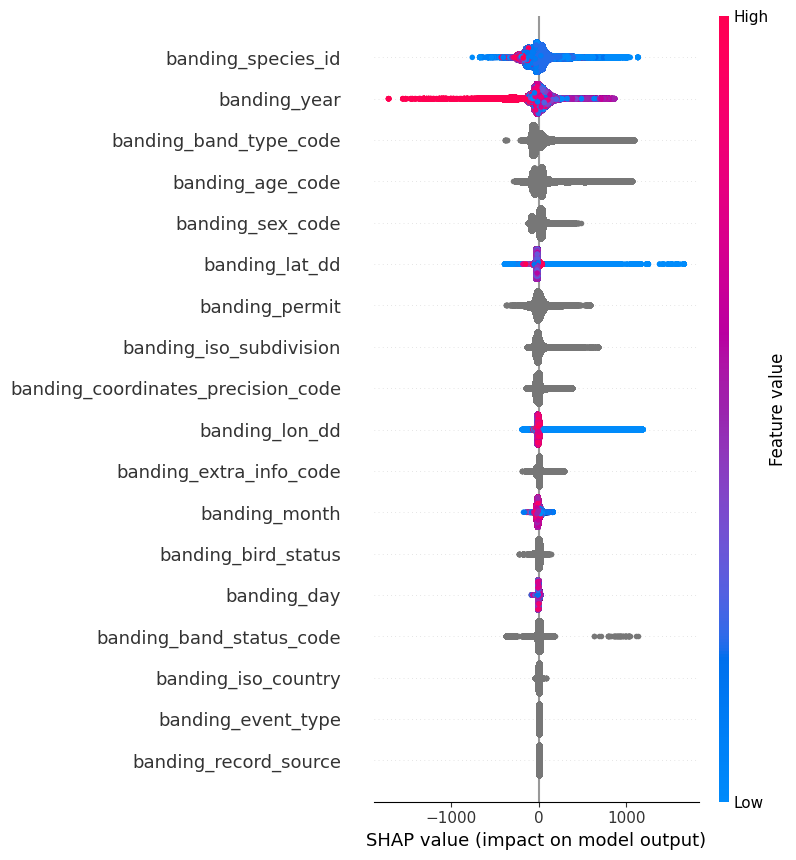

In [18]:
shap.summary_plot(shap_values, X_test)

## Error Analysis

In [19]:
# combine preds with xtest and y_test for error analysis
error_analysis_df = X_test.copy()
error_analysis_df['true_event_days_span'] = y_test
error_analysis_df['predicted_event_days_span'] = predictions
error_analysis_df['absolute_error'] = np.abs(error_analysis_df['true_event_days_span'] - error_analysis_df['predicted_event_days_span'])
error_analysis_df['relative_error'] = error_analysis_df['absolute_error'] / error_analysis_df['true_event_days_span'].replace(0, np.nan)

# bin ranges of error in error_analysis_df
def error_bin(rel_error):
    if rel_error < 0.1:
        return '<10%'
    elif rel_error < 0.25:
        return '10-25%'
    elif rel_error < 0.5:
        return '25-50%'
    elif rel_error < 1.0:
        return '50-100%'
    else:
        return '>100%'

error_analysis_df['error_bin'] = error_analysis_df['relative_error'].apply(error_bin)
error_analysis_df.reset_index(drop=True, inplace=True)  


# top 10 absolute errors
error_analysis_df.sort_values(by='absolute_error', ascending=False).head(10)



# top 5 error < 10% bin
#error_analysis_df[error_analysis_df['error_bin'] == '<10%'].sort_values(by='absolute_error', ascending=False).head(5)

,banding_day,banding_month,banding_year,banding_species_id,banding_iso_country,banding_iso_subdivision,banding_band_type_code,banding_bird_status,banding_age_code,banding_sex_code,...,banding_lat_dd,banding_lon_dd,banding_coordinates_precision_code,banding_permit,banding_record_source,true_event_days_span,predicted_event_days_span,absolute_error,relative_error,error_bin
97224,20,8,1960,1330,CA,CA-QC,11,3,2,5,...,46.50000,-72.50000,60.0,P3935689,B,23375,342.247159,23032.752841,0.985358,50-100%
831473,2,6,1960,510,US,US-MI,11,3,4,0,...,44.75000,-83.25000,10.0,P0920660,B,23754,734.452919,23019.547081,0.969081,50-100%
800112,15,6,1960,540,US,US-MI,11,3,4,0,...,45.41667,-83.75000,10.0,P0905838,B,23477,1026.292226,22450.707774,0.956285,50-100%
93051,25,10,1960,1690,US,US-CA,11,3,1,4,...,41.50000,-121.50000,60.0,P1981861,B,23419,1394.541287,22024.458713,0.940453,50-100%
598249,11,8,1962,1320,US,US-CA,11,4,4,0,...,34.50000,-118.50000,60.0,P2927972,B,22195,358.966143,21836.033857,0.983827,50-100%
39739,21,6,1962,510,US,US-MI,11,3,4,0,...,45.58333,-86.58333,10.0,P9907747,B,22617,977.034264,21639.965736,0.956801,50-100%
745809,28,6,1963,1320,US,US-NY,11,4,2,0,...,43.50000,-76.50000,60.0,P8938878,B,21932,321.328743,21610.671257,0.985349,50-100%
568424,16,9,1963,1320,US,US-WI,18,3,1,5,...,43.50000,-88.50000,60.0,P8988788,B,22052,573.630401,21478.369599,0.973987,50-100%
596614,14,2,1960,1320,US,US-NY,11,3,1,5,...,40.50000,-72.50000,60.0,P2925999,B,21952,620.805532,21331.194468,0.971720,50-100%
109357,17,11,1961,1440,US,US-GA,11,3,1,4,...,30.50000,-82.50000,60.0,P7976272,B,21953,654.729319,21298.270681,0.970176,50-100%


In [20]:

#shap.force_plot(explainer.expected_value, shap_values[0,:], X.iloc[0,:], matplotlib=True)

#select only 1 row for force plot
rowid = 831473
X = X_test.iloc[rowid:rowid+1,:]
fp_shap_values = shap_values[rowid:rowid+1,:]


shap_html = shap.force_plot(explainer.expected_value, fp_shap_values, X, matplotlib=False)

# Custom CSS to make background white
custom_css = """
<style>
.shap-force-plot {
    background-color: white !important;
}
.shap-force-plot svg {
    background-color: white !important;
}
</style>
"""



from IPython.display import display, HTML
#display(HTML(shap.getjs() + shap_html.html()))
display(HTML(custom_css + shap.getjs() + shap_html.html()))



In [21]:
#error_analysis_df.banding_coordinates_precision_code.value_counts()

# error bin counts where species_id = 510 grouped by banding_coordinates_precision_code
species_id = 510
species_error_df = error_analysis_df[error_analysis_df['banding_species_id'] == species_id]
species_error_counts = species_error_df.groupby(['banding_coordinates_precision_code', 'error_bin']).size().unstack(fill_value=0)
species_error_counts

error_bin,10-25%,25-50%,50-100%,<10%,>100%
banding_coordinates_precision_code,,,,,
0.0,19,57,67,16,129
1.0,13,36,50,12,57
10.0,213,467,857,141,2134


In [22]:
# overpredicted top 5
error_analysis_df[error_analysis_df['predicted_event_days_span'] > error_analysis_df['true_event_days_span']].sort_values(by='absolute_error', ascending=False).head(5)


,banding_day,banding_month,banding_year,banding_species_id,banding_iso_country,banding_iso_subdivision,banding_band_type_code,banding_bird_status,banding_age_code,banding_sex_code,...,banding_lat_dd,banding_lon_dd,banding_coordinates_precision_code,banding_permit,banding_record_source,true_event_days_span,predicted_event_days_span,absolute_error,relative_error,error_bin
56374,8,7,1994,821,US,US-UM,51,3,4,0,...,28.25,-177.41667,10.0,P4994649,B,242,8444.055218,8202.055218,33.892790,>100%
187141,19,6,1995,821,US,US-UM,51,3,4,0,...,28.25,-177.41667,10.0,P4994649,B,70,8107.412911,8037.412911,114.820184,>100%
216804,4,7,2001,821,US,US-UM,53,3,4,0,...,28.25,-177.41667,10.0,P6964129,B,126,7640.463015,7514.463015,59.638595,>100%
359421,6,7,1994,821,US,US-UM,51,3,4,0,...,28.25,-177.41667,10.0,P4994649,B,1021,8449.221005,7428.221005,7.275437,>100%
644079,8,4,1997,821,US,US-UM,51,3,4,0,...,28.25,-177.41667,10.0,P6964129,B,84,7438.844620,7354.844620,87.557674,>100%


In [23]:

#shap.force_plot(explainer.expected_value, shap_values[0,:], X.iloc[0,:], matplotlib=True)

#select only 1 row for force plot
rowid = 56374
X = X_test.iloc[rowid:rowid+1,:]
fp_shap_values = shap_values[rowid:rowid+1,:]


shap_html = shap.force_plot(explainer.expected_value, fp_shap_values, X, matplotlib=False)

# Custom CSS to make background white
custom_css = """
<style>
.shap-force-plot {
    background-color: white !important;
}
.shap-force-plot svg {
    background-color: white !important;
}
</style>
"""



from IPython.display import display, HTML
#display(HTML(shap.getjs() + shap_html.html()))
display(HTML(custom_css + shap.getjs() + shap_html.html()))



In [24]:
# top error where lat > 25 and lon > -124.5 and in < 10% error bin
error_analysis_df[(error_analysis_df['banding_lat_dd'] > 25) & 
                  (error_analysis_df['banding_lon_dd'] > -124.5) & 
                  (error_analysis_df['error_bin'] == '<10%')].sort_values(by='absolute_error', ascending=False).head(5)

,banding_day,banding_month,banding_year,banding_species_id,banding_iso_country,banding_iso_subdivision,banding_band_type_code,banding_bird_status,banding_age_code,banding_sex_code,...,banding_lat_dd,banding_lon_dd,banding_coordinates_precision_code,banding_permit,banding_record_source,true_event_days_span,predicted_event_days_span,absolute_error,relative_error,error_bin
79948,14,6,2007,743,US,US-CA,11,3,4,0,...,33.08333,-117.25000,10.0,P3733151,B,3628,3288.836004,339.163996,0.093485,<10%
392648,8,6,2008,743,US,US-CA,01,3,4,0,...,33.25000,-117.41667,10.0,P3733151,B,3644,3307.170099,336.829901,0.092434,<10%
81434,10,6,1997,743,US,US-CA,04,3,4,0,...,33.25000,-117.41667,10.0,P3733151,B,4031,3694.409217,336.590783,0.083501,<10%
658418,14,6,2007,743,US,US-CA,04,3,4,0,...,33.08333,-117.25000,10.0,P3733151,B,3622,3296.137968,325.862032,0.089967,<10%
130392,15,6,2006,743,US,US-CA,01,3,4,0,...,33.25000,-117.41667,10.0,P3733151,B,3633,3314.284120,318.715880,0.087728,<10%


In [25]:
# average true event days span and count where species_id = 743 and year is 2007
species_id = 743
year = 2007
species_year_df = error_analysis_df[error_analysis_df['banding_species_id'] == species_id]
species_year_df = species_year_df[species_year_df['banding_year'] == year]
avg_event_days_span = species_year_df['true_event_days_span'].mean()
count_records = species_year_df.shape[0]
print(f"Species ID: {species_id}, Year: {year}, Average Event Days Span: {avg_event_days_span}, Record Count: {count_records}")

# average true event days span for species_id = 743 all years
species_id = 743
species_df = error_analysis_df[error_analysis_df['banding_species_id'] == species_id]
avg_event_days_span = species_df['true_event_days_span'].mean()
count_records = species_df.shape[0]
print(f"Species ID: {species_id}, Average Event Days Span: {avg_event_days_span}, Record Count: {count_records}")

# average true event days span and count for speciess_id = 743 by year
species_id = 743
species_df = error_analysis_df[error_analysis_df['banding_species_id'] == species_id]
avg_event_days_by_year = species_df.groupby('banding_year')['true_event_days_span'].agg(['mean', 'count']).reset_index()
print(f"Species ID: {species_id} Average Event Days Span by Year:")
print(avg_event_days_by_year)

Species ID: 743, Year: 2007, Average Event Days Span: 3391.6666666666665, Record Count: 9
Species ID: 743, Average Event Days Span: 1548.0680272108843, Record Count: 441
Species ID: 743 Average Event Days Span by Year:
    banding_year         mean  count
0           1963  2189.000000      1
1           1967  5477.000000      1
2           1973  1094.000000      1
3           1976  1836.500000      2
4           1977  2890.500000      2
5           1978  2245.250000      4
6           1979  1442.500000      2
7           1980  2817.000000      4
8           1981  1996.500000      2
9           1984  1420.000000      1
10          1985  1641.000000      2
11          1986  7359.000000      1
12          1988  3659.000000      4
13          1990  3652.500000      2
14          1991  3919.666667      3
15          1992  8022.000000      1
16          1993     0.000000      1
17          1994  4090.200000      5
18          1995  5112.333333      3
19          1996  3972.000000      8
20  

In [26]:

#shap.force_plot(explainer.expected_value, shap_values[0,:], X.iloc[0,:], matplotlib=True)

#select only 1 row for force plot
rowid = 79948
X = X_test.iloc[rowid:rowid+1,:]
fp_shap_values = shap_values[rowid:rowid+1,:]


shap_html = shap.force_plot(explainer.expected_value, fp_shap_values, X, matplotlib=False)

# Custom CSS to make background white
custom_css = """
<style>
.shap-force-plot {
    background-color: white !important;
}
.shap-force-plot svg {
    background-color: white !important;
}
</style>
"""



from IPython.display import display, HTML
#display(HTML(shap.getjs() + shap_html.html()))
display(HTML(custom_css + shap.getjs() + shap_html.html()))



## Other Results Analysis

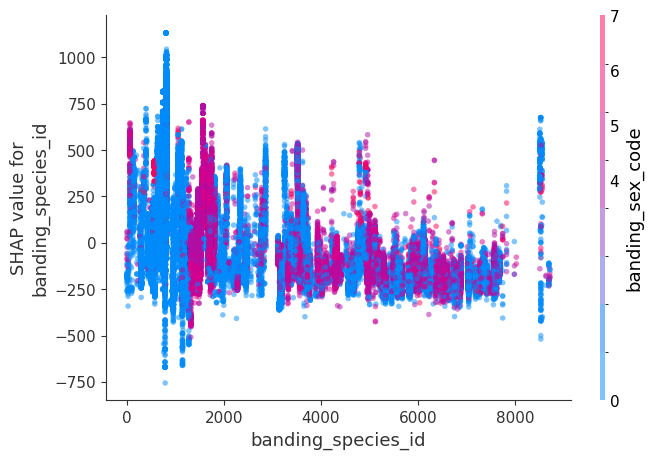

In [27]:
shap.dependence_plot("banding_species_id", shap_values, X_test, interaction_index='auto', alpha=0.5)

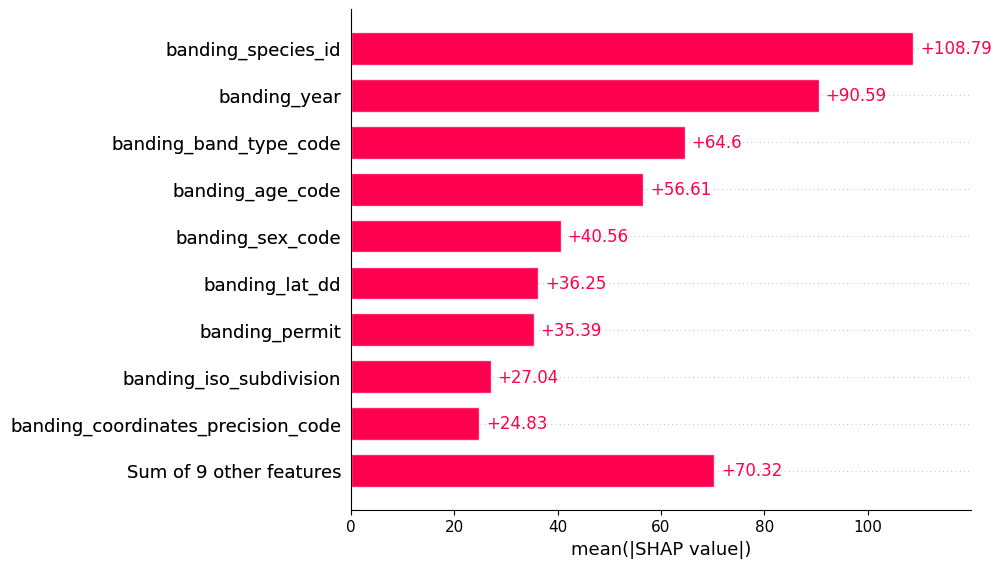

In [28]:
shap.plots.bar(explainer(X_test))

In [ ]:
species = lookup.species[['SPECIES_ID','SPECIES_NAME','SCI_NAME']]

# Merge with the high impact species

high_impact_species_col = high_impact_species.reset_index()

# high_impact_species_col = high_impact_species_col.merge(
#     species,
#     left_on='species_id',
#     right_on='SPECIES_ID',
#     how='left'
# )

high_impact_species_col


species_id  shap_value                   
                      mean  count         std
0          811  635.435903    130   82.548143
1         1570  607.766551    283   93.701682
2         8522  549.233560     41   70.379179
3          400  494.703172    111  146.983804
4          821  491.039443  19375  204.041824
..         ...         ...    ...         ...
634       1850 -322.256935      3    1.222228
635       3140 -335.504037    103   16.702395
636       1321 -381.240580     27   43.353355
637       1282 -387.263757     82   21.585977
638       8553 -401.594909      2    6.696440

[639 rows x 4 columns]

In [34]:
# altair histogram of event_days_span
chart = alt.Chart(df_banding_pd).mark_bar().encode(
    alt.X("event_days_span", bin=alt.Bin(maxbins=1000)),
    y='count()',
).properties(
    title="Distribution of Event Days Span",
    width=800,
    height=400
)

chart

alt.Chart(...)

In [35]:
# altair histogram of banding_year
chart = alt.Chart(df_banding_pd).mark_bar().encode(
    alt.X("banding_year", bin=alt.Bin(maxbins=100)),
    y='count()',
).properties(
    title="Distribution of Banding Year",
    width=800,
    height=400
)   

chart

alt.Chart(...)

In [36]:
#df_banding_pd['banding_year'].quantile([.95])

In [ ]:
# Get feature importances 
feature_importance = best_model.get_feature_importance()
feature_names = best_model.feature_names_



importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df)

NameError: name 'best_model' is not defined